# Titanic Dataset Analysis
## Data Science with Python Internship – Task 2

### Objective
Analyze survival patterns in the Titanic dataset and visualize key insights using Python, Pandas, Matplotlib, and Seaborn.

In [59]:
import os

print(os.listdir())


['.config', 'titanic (1).zip', 'titanic_data', 'titanic.zip', 'titanic (2).zip', 'sample_data']


In [60]:
from google.colab import files

uploaded = files.upload()


Saving titanic.zip to titanic (3).zip


In [61]:
import os
print(os.listdir())

['.config', 'titanic (1).zip', 'titanic (3).zip', 'titanic_data', 'titanic.zip', 'titanic (2).zip', 'sample_data']


In [62]:
import zipfile

with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall("titanic_data")

print("Extraction completed")

Extraction completed


In [63]:
import os

print(os.listdir("titanic_data"))

['test.csv', 'train.csv', 'gender_submission.csv']


In [64]:
import pandas as pd

df = pd.read_csv("titanic_data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [65]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [67]:
df.shape

(891, 12)

Dataset contains 891 passenger records and 12 features including age, gender, class, fare, and survival status.

In [68]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Missing Values Observed

- Age: 177 missing values
- Cabin: 687 missing values
- Embarked: 2 missing values

In [69]:

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [70]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [71]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [72]:
df.drop("Cabin", axis=1, inplace=True)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


Data Cleaning

1. Identified missing values using df.isnull().sum().

2. Filled missing Age values with the median age to preserve data distribution.

3. Filled missing Embarked values with the most frequent embarkation port.

4. Dropped the Cabin column because more than 75% of its values were missing.

In [74]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [75]:
bins = [0,12,18,35,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3757/4115614558.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean().reset_index()


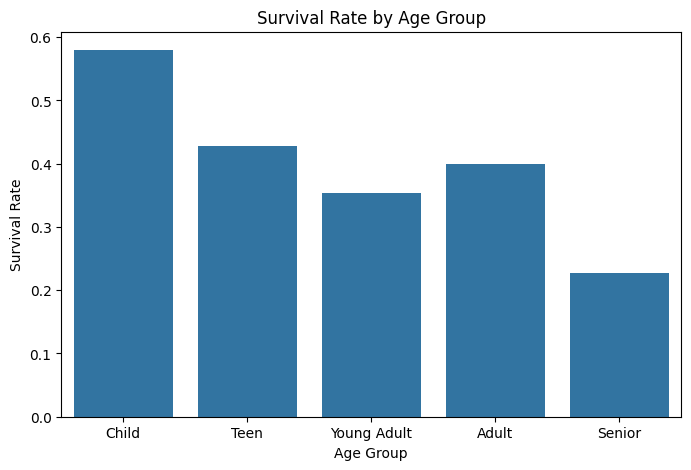

In [77]:
age_survival = df.groupby("AgeGroup")["Survived"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="AgeGroup", y="Survived", data=age_survival)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

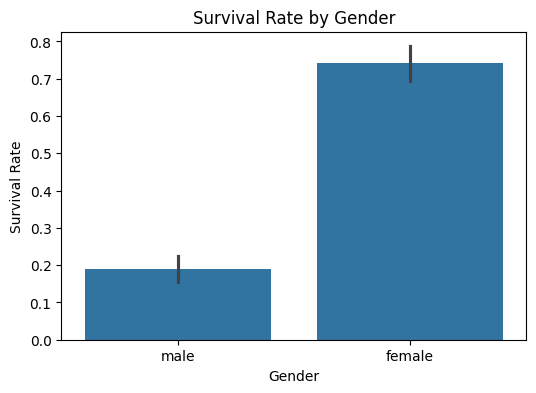

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

Female passengers had a significantly higher survival rate than male passengers.

In [79]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


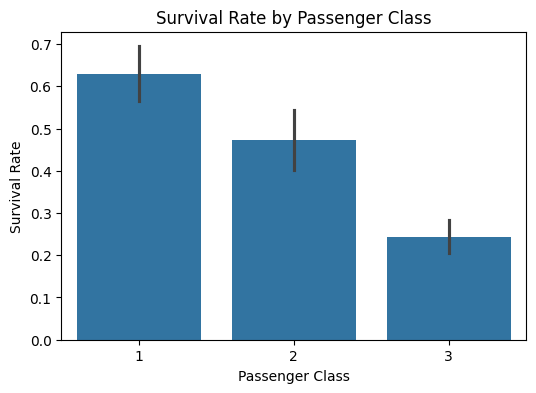

In [80]:
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest.

In [81]:
bins = [0,12,18,35,60,100]
labels = ["Child","Teen","Young Adult","Adult","Senior"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [82]:
df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipykernel_3757/2602041343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


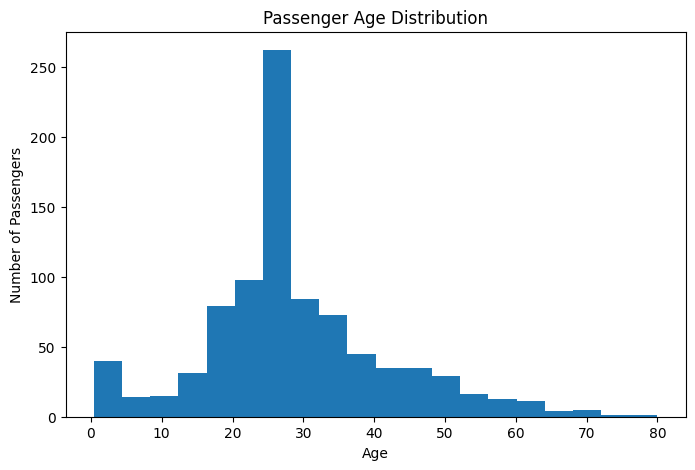

In [83]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Most passengers were between 20 and 40 years old.

# Conclusion

1. Female passengers had a significantly higher survival rate than male passengers.

2. Passenger class strongly influenced survival chances. First-class passengers were more likely to survive than second- and third-class passengers.

3. Younger passengers generally had better survival outcomes than older passengers.

4. Most passengers on board were between 20 and 40 years of age.

5. Gender and passenger class were the most important factors affecting survival on the Titanic.

Overall, the analysis demonstrates how demographic and socioeconomic factors influenced survival outcomes during the Titanic disaster.